# EDA - Hypothesis Validation
Validating H1-H5 against the filtered LendingClub dataset.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_parquet('../data/loans_filtered.parquet')
print('Shape:', df.shape)
print('Target counts:')
print(df['target'].value_counts())

Shape: (1348092, 152)
Target counts:
target
0.0    1078739
1.0     269320
Name: count, dtype: int64


## H1: Higher DTI -> Higher Default

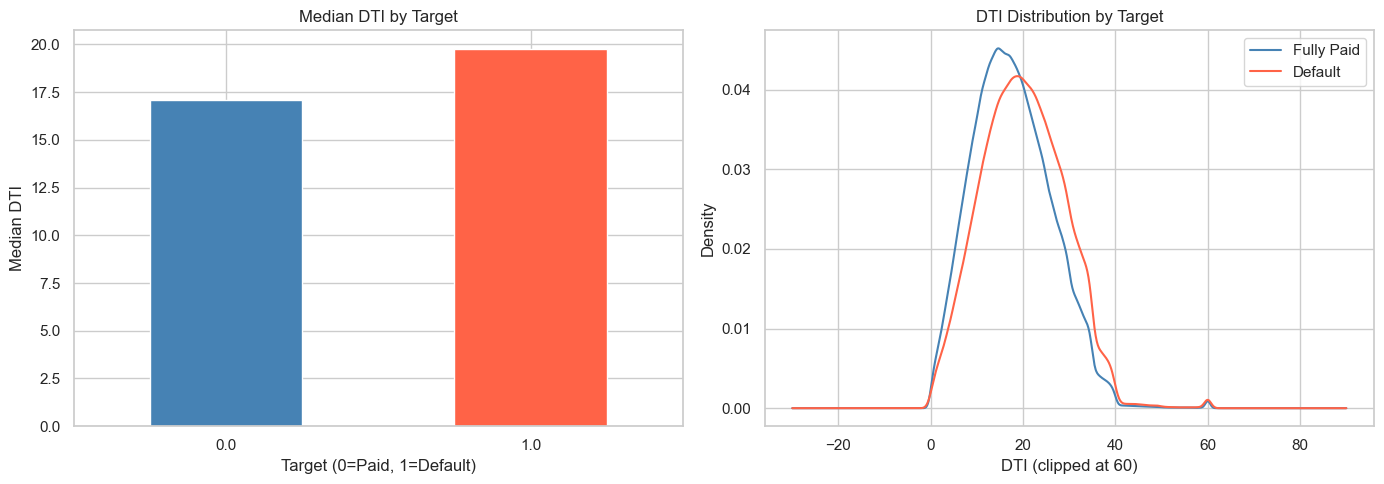

Median DTI:
target
0.0    17.10
1.0    19.75
Name: dti, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('target')['dti'].median().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Median DTI by Target')
axes[0].set_xlabel('Target (0=Paid, 1=Default)')
axes[0].set_ylabel('Median DTI')
axes[0].tick_params(axis='x', rotation=0)

for t, label, color in [(0, 'Fully Paid', 'steelblue'), (1, 'Default', 'tomato')]:
    df[df['target']==t]['dti'].dropna().clip(0, 60).plot.kde(ax=axes[1], label=label, color=color)
axes[1].set_title('DTI Distribution by Target')
axes[1].set_xlabel('DTI (clipped at 60)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/h1_dti.png', dpi=100)
plt.show()

print('Median DTI:')
print(df.groupby('target')['dti'].median())

## H2: Shorter Credit History -> Higher Default

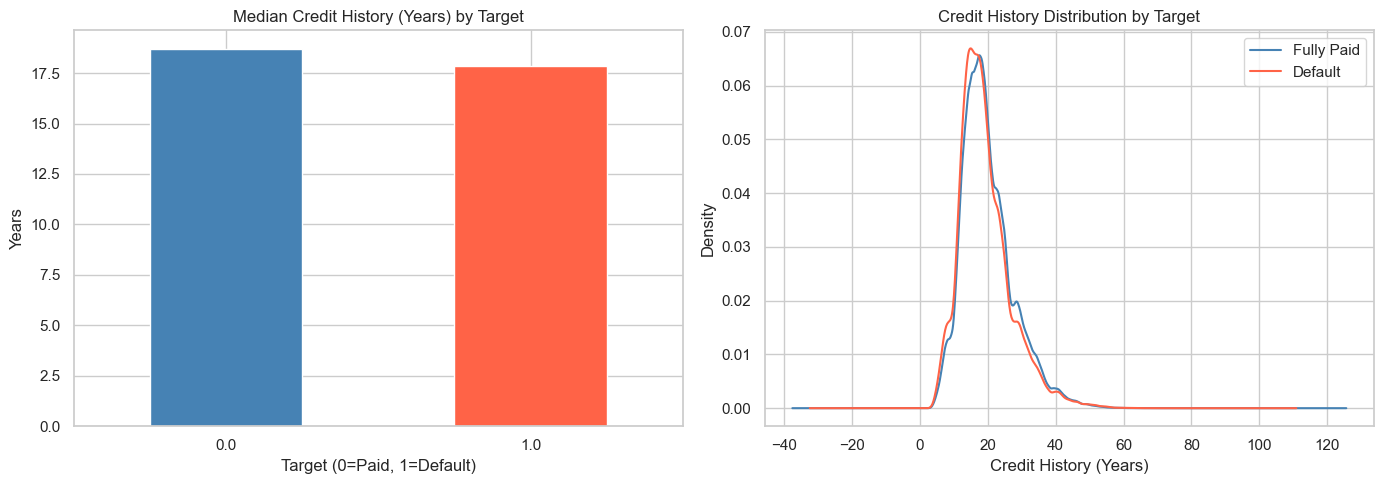

Median Credit History (years):
target
0.0    18.679452
1.0    17.846575
Name: credit_history_years, dtype: float64


In [12]:
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
df['credit_history_years'] = (pd.Timestamp('2018-12-31') - df['earliest_cr_line']).dt.days / 365

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('target')['credit_history_years'].median().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Median Credit History (Years) by Target')
axes[0].set_xlabel('Target (0=Paid, 1=Default)')
axes[0].set_ylabel('Years')
axes[0].tick_params(axis='x', rotation=0)

for t, label, color in [(0, 'Fully Paid', 'steelblue'), (1, 'Default', 'tomato')]:
    df[df['target']==t]['credit_history_years'].dropna().plot.kde(ax=axes[1], label=label, color=color)
axes[1].set_title('Credit History Distribution by Target')
axes[1].set_xlabel('Credit History (Years)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/h2_credit_history.png', dpi=100)
plt.show()

print('Median Credit History (years):')
print(df.groupby('target')['credit_history_years'].median())

## H3: Certain Loan Purposes -> Higher Risk

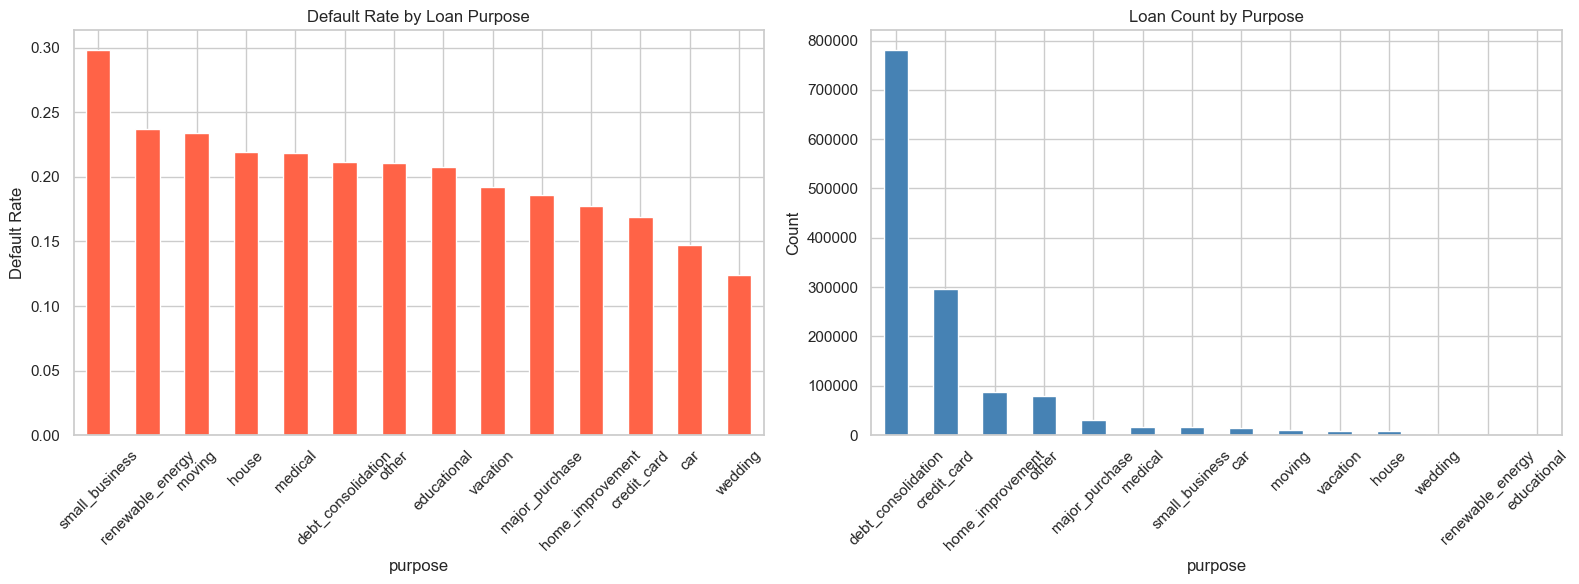

Default rate by purpose:
purpose
small_business        0.299
renewable_energy      0.237
moving                0.234
house                 0.219
medical               0.218
debt_consolidation    0.212
other                 0.211
educational           0.208
vacation              0.192
major_purchase        0.186
home_improvement      0.178
credit_card           0.169
car                   0.147
wedding               0.124
Name: target, dtype: float64


In [13]:
purpose_risk = df.groupby('purpose')['target'].mean().sort_values(ascending=False)
purpose_counts = df.groupby('purpose')['target'].count()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

purpose_risk.plot(kind='bar', ax=axes[0], color='tomato')
axes[0].set_title('Default Rate by Loan Purpose')
axes[0].set_ylabel('Default Rate')
axes[0].tick_params(axis='x', rotation=45)

purpose_counts.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Loan Count by Purpose')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/h3_purpose.png', dpi=100)
plt.show()

print('Default rate by purpose:')
print(purpose_risk.round(3))

## H4: Lower Income -> Higher Default

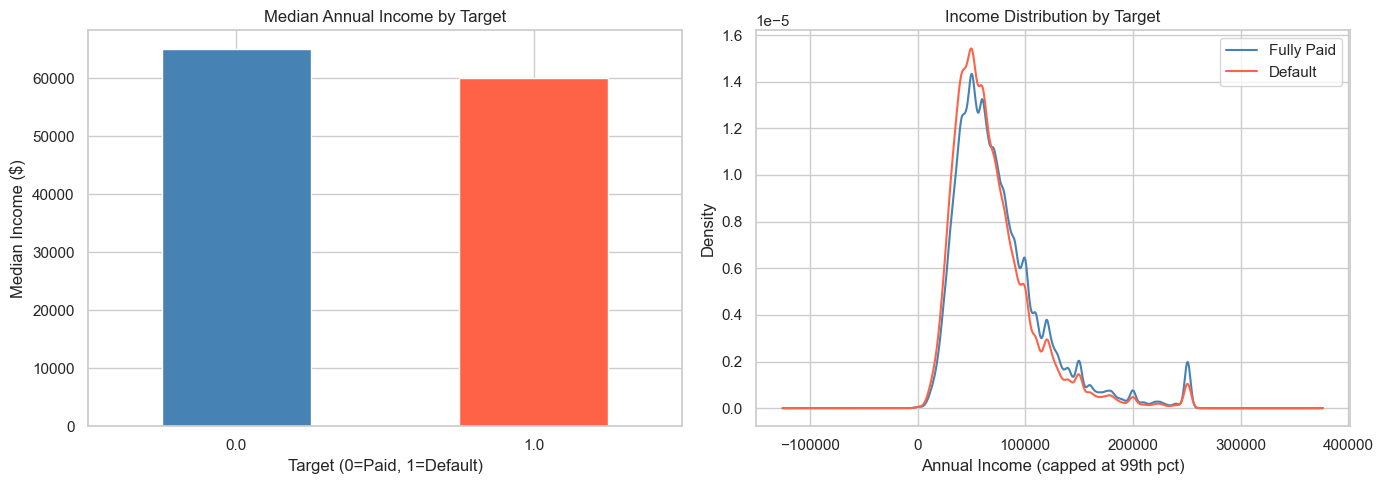

Median Annual Income:
target
0.0    65000.0
1.0    60000.0
Name: annual_inc_capped, dtype: float64


In [14]:
income_cap = df['annual_inc'].quantile(0.99)
df['annual_inc_capped'] = df['annual_inc'].clip(0, income_cap)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('target')['annual_inc_capped'].median().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Median Annual Income by Target')
axes[0].set_xlabel('Target (0=Paid, 1=Default)')
axes[0].set_ylabel('Median Income ($)')
axes[0].tick_params(axis='x', rotation=0)

for t, label, color in [(0, 'Fully Paid', 'steelblue'), (1, 'Default', 'tomato')]:
    df[df['target']==t]['annual_inc_capped'].dropna().plot.kde(ax=axes[1], label=label, color=color)
axes[1].set_title('Income Distribution by Target')
axes[1].set_xlabel('Annual Income (capped at 99th pct)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/h4_income.png', dpi=100)
plt.show()

print('Median Annual Income:')
print(df.groupby('target')['annual_inc_capped'].median())

## H5: More Derogatory Marks -> Higher Default

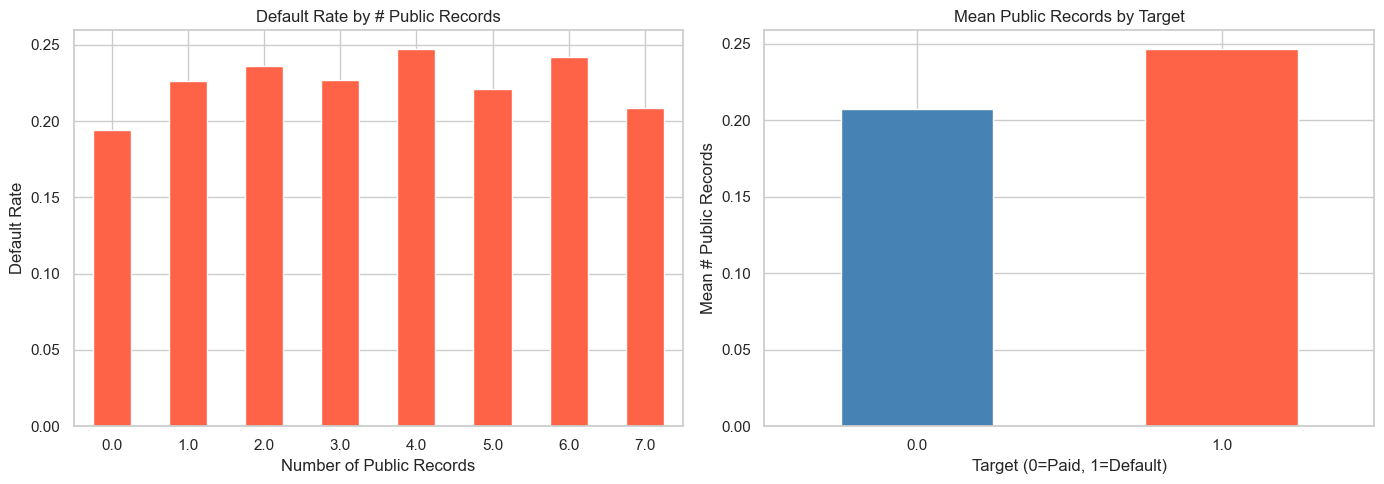

Mean pub_rec by target:
target
0.0    0.207
1.0    0.246
Name: pub_rec, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pub_rec_rate = df.groupby('pub_rec')['target'].mean().head(8)
pub_rec_rate.plot(kind='bar', ax=axes[0], color='tomato')
axes[0].set_title('Default Rate by # Public Records')
axes[0].set_xlabel('Number of Public Records')
axes[0].set_ylabel('Default Rate')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('target')['pub_rec'].mean().plot(kind='bar', ax=axes[1], color=['steelblue','tomato'])
axes[1].set_title('Mean Public Records by Target')
axes[1].set_xlabel('Target (0=Paid, 1=Default)')
axes[1].set_ylabel('Mean # Public Records')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../data/h5_derogatory.png', dpi=100)
plt.show()

print('Mean pub_rec by target:')
print(df.groupby('target')['pub_rec'].mean().round(3))

## Hypothesis Summary

In [16]:
summary = {
    'Hypothesis': ['H1: Higher DTI', 'H2: Shorter Credit History', 'H3: Loan Purpose', 'H4: Lower Income', 'H5: More Derogatory Marks'],
    'Feature': ['dti', 'credit_history_years', 'purpose', 'annual_inc', 'pub_rec'],
    'Default_val': [
        round(df[df['target']==1]['dti'].median(), 2),
        round(df[df['target']==1]['credit_history_years'].median(), 2),
        'See chart',
        round(df[df['target']==1]['annual_inc_capped'].median(), 2),
        round(df[df['target']==1]['pub_rec'].mean(), 3)
    ],
    'Paid_val': [
        round(df[df['target']==0]['dti'].median(), 2),
        round(df[df['target']==0]['credit_history_years'].median(), 2),
        'See chart',
        round(df[df['target']==0]['annual_inc_capped'].median(), 2),
        round(df[df['target']==0]['pub_rec'].mean(), 3)
    ]
}
print(pd.DataFrame(summary).to_string(index=False))

                Hypothesis              Feature Default_val  Paid_val
            H1: Higher DTI                  dti       19.75      17.1
H2: Shorter Credit History credit_history_years       17.85     18.68
          H3: Loan Purpose              purpose   See chart See chart
          H4: Lower Income           annual_inc     60000.0   65000.0
 H5: More Derogatory Marks              pub_rec       0.246     0.207
